# 06 — Image Rendering with the SDK

`client.weather.gen_grid_image(grid, analysis_type=...)` returns a PNG
byte-string from a 2D grid of values, using Infrared's canonical
colormap for that analysis type. No matplotlib required, and the
colours match what you see elsewhere in the platform.

Two things to be aware of:

1. **Orientation.** The SDK's grids use `row 0 = south`. PNG row 0 is
   the **top** of the image. So you need `np.flipud(grid)` before sending
   to `gen_grid_image` if you want north-up.
2. **Colormap saturation.** Each `analysis_type` ships with a fixed
   value range tuned for typical results. If your grid is bimodal or
   compressed near one end, the standard colormap can mask detail.
   Render without `analysis_type` to get a default linear colormap
   stretched to your data.

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

from infrared_sdk import InfraredClient
from infrared_sdk.analyses.types import AnalysesName, WindModelRequest
from infrared_sdk.tiling.merger import grid_to_list
from cities import get

OUTPUT_DIR = os.path.join(".", "_outputs_06")
os.makedirs(OUTPUT_DIR, exist_ok=True)

city = get("munich")

## 1. Run a quick analysis

In [2]:
with InfraredClient() as client:
    area = client.buildings.get_area(city.polygon_small)
    [result] = client.run_area_and_wait(
        [WindModelRequest(analysis_type=AnalysesName.wind_speed,
                          wind_speed=5, wind_direction=270)],
        city.polygon_small,
        buildings=area.buildings,
    )
import numpy as np
valid = result.merged_grid[~np.isnan(result.merged_grid)]
print(f"grid shape  : {result.grid_shape}")
print(f"value range : {float(valid.min()):.2f} .. {float(valid.max()):.2f} m/s")

grid shape  : (256, 256)
value range : 0.44 .. 6.34 m/s


## 2. Render with the canonical wind colormap

Pass `analysis_type` so the server picks the right colormap.
**Important:** flip vertically so north ends up at the top of the PNG.

wrote .\_outputs_06\wind_canonical.png  (52375 bytes)


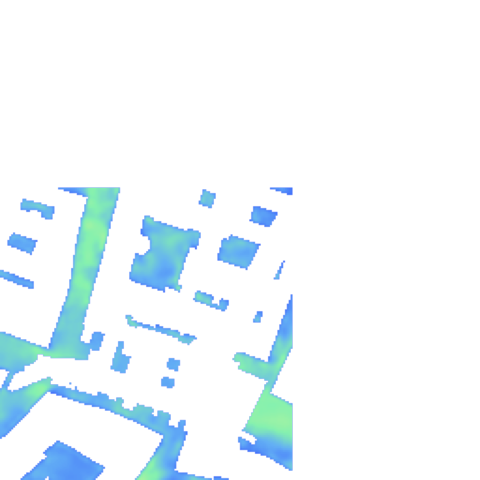

In [3]:
flipped = np.flipud(result.merged_grid)
with InfraredClient() as client:
    png = client.weather.gen_grid_image(
        grid=grid_to_list(flipped),
        analysis_type=str(AnalysesName.wind_speed),
    )

out = os.path.join(OUTPUT_DIR, "wind_canonical.png")
with open(out, "wb") as f: f.write(png)
print(f"wrote {out}  ({len(png)} bytes)")
Image.open(BytesIO(png))

## 3. Render WITHOUT `analysis_type` for default rescaling

Useful when the canonical colormap saturates the interesting part of
your distribution.

wrote .\_outputs_06\wind_default.png  (59352 bytes)


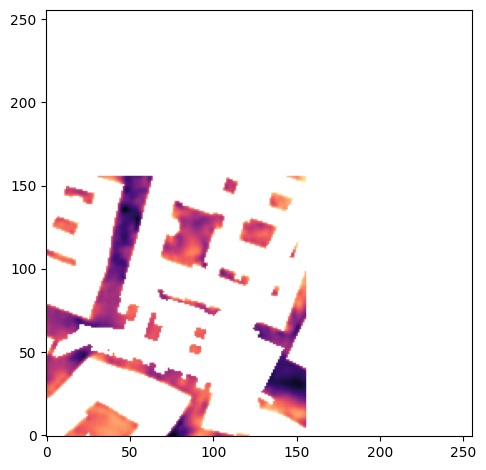

In [4]:
with InfraredClient() as client:
    png_default = client.weather.gen_grid_image(grid=grid_to_list(flipped))

out2 = os.path.join(OUTPUT_DIR, "wind_default.png")
with open(out2, "wb") as f: f.write(png_default)
print(f"wrote {out2}  ({len(png_default)} bytes)")
Image.open(BytesIO(png_default))

## 4. Demonstrate the orientation gotcha

Here's what happens if you skip the flip -- north ends up at the bottom
of the rendered PNG.

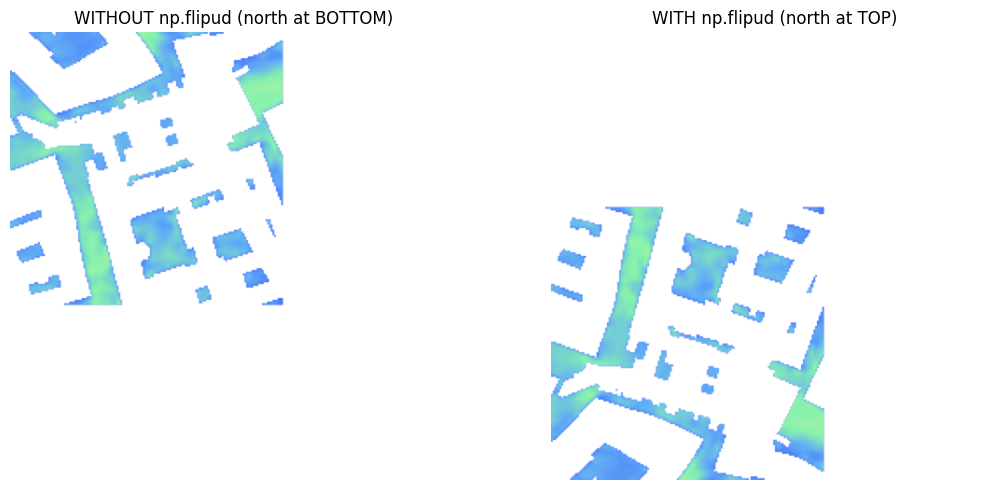

In [5]:
with InfraredClient() as client:
    png_unflipped = client.weather.gen_grid_image(
        grid=grid_to_list(result.merged_grid),
        analysis_type=str(AnalysesName.wind_speed),
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(np.array(Image.open(BytesIO(png_unflipped))))
axes[0].set_title("WITHOUT np.flipud (north at BOTTOM)")
axes[0].axis("off")
axes[1].imshow(np.array(Image.open(BytesIO(png))))
axes[1].set_title("WITH np.flipud (north at TOP)")
axes[1].axis("off")
plt.tight_layout(); plt.show()

## 5. PWC and TCS need extra arguments

For `pedestrian-wind-comfort` and `thermal-comfort-statistics`, pass
`criteria=` or `subtype=` so the server picks the right discrete-class
palette:

```python
client.weather.gen_grid_image(
    grid=grid_to_list(np.flipud(result.merged_grid)),
    analysis_type=str(AnalysesName.pedestrian_wind_comfort),
    criteria=str(PwcCriteria.lawson_lddc),
)
```

The signature is:

```python
gen_grid_image(*, grid, analysis_type=None, criteria=None, subtype=None) -> bytes
```

That's the full rendering surface. Next: `07_async_and_webhooks.ipynb`.